# TP3 — Redes Neurais do Zero com Interpretabilidade
## Breast Cancer Wisconsin (Diagnóstico)

Dataset com 569 instâncias e 30 features numéricas extraídas de imagens de aspiração por agulha fina (FNA) de massas mamárias. Dez características de núcleos celulares, cada uma com três variantes: média, erro padrão e pior valor. Duas classes: **B** (benigno, 357) e **M** (maligno, 212).

A MLP é implementada do zero com NumPy: forward pass, backpropagation, ReLU (camadas escondidas), Softmax (saída) e Cross-Entropy. Treinamento via mini-batch gradient descent.

In [1]:
import os
os.makedirs('images', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from mlp import MLP

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

### Carregamento dos dados
Leitura do arquivo `wdbc.data` com os nomes das colunas conforme `wdbc.names`.

In [2]:
feature_names = [
    'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
    'mean_smoothness', 'mean_compactness', 'mean_concavity',
    'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension',
    'se_radius', 'se_texture', 'se_perimeter', 'se_area',
    'se_smoothness', 'se_compactness', 'se_concavity',
    'se_concave_points', 'se_symmetry', 'se_fractal_dimension',
    'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area',
    'worst_smoothness', 'worst_compactness', 'worst_concavity',
    'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension'
]

column_names = ['id', 'diagnosis'] + feature_names
df = pd.read_csv('data/wdbc.data', header=None, names=column_names)
df.drop('id', axis=1, inplace=True)
df.head()

,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(f'Shape: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')
print(f'Tipos:\n{df.dtypes.value_counts().to_string()}')
print(f'Valores ausentes: {df.isnull().sum().sum()}')

Shape: (569, 31)
Colunas: ['diagnosis', 'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'se_radius', 'se_texture', 'se_perimeter', 'se_area', 'se_smoothness', 'se_compactness', 'se_concavity', 'se_concave_points', 'se_symmetry', 'se_fractal_dimension', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']
Tipos:
float64    30
str         1
Valores ausentes: 0


### Distribuição das classes
O dataset é moderadamente desbalanceado: 62,7% benigno e 37,3% maligno.

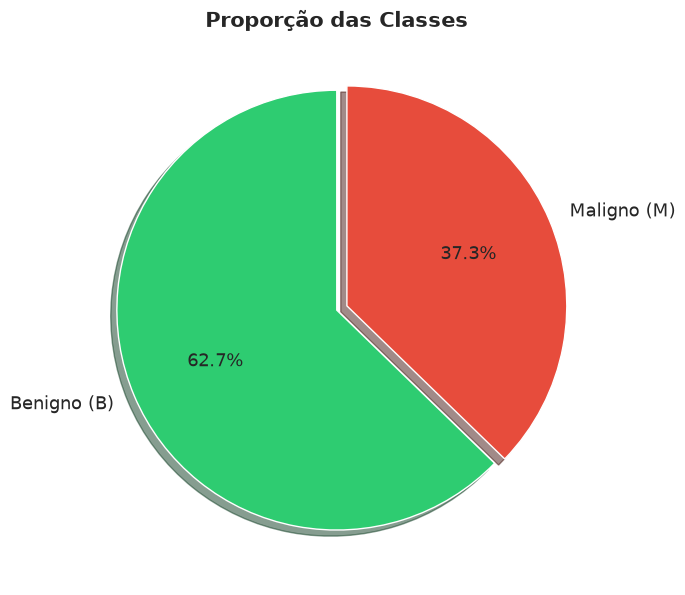

Benigno: 357 (62.7%)
Maligno: 212 (37.3%)
Razão B/M: 1.68


In [4]:
counts = df['diagnosis'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#2ecc71', '#e74c3c']
ax.pie(counts.values, labels=['Benigno (B)', 'Maligno (M)'],
       autopct='%1.1f%%', colors=colors, explode=(0, 0.05),
       shadow=True, startangle=90, textprops={'fontsize': 13})
ax.set_title('Proporção das Classes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/01_distribuicao_classes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Benigno: {counts['B']} ({100*counts['B']/len(df):.1f}%)")
print(f"Maligno: {counts['M']} ({100*counts['M']/len(df):.1f}%)")
print(f"Razão B/M: {counts['B']/counts['M']:.2f}")

### Estatísticas descritivas
Resumo estatístico das 30 features. As escalas variam muito entre features (ex: `mean_area` vai de 143 a 2501, enquanto `mean_smoothness` vai de 0,05 a 0,16), o que exige padronização antes do treinamento.

In [5]:
df[feature_names].describe().T.style.background_gradient(cmap='Blues', axis=0)

,count,mean,std,min,25%,50%,75%,max
mean_radius,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
mean_texture,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
mean_perimeter,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
mean_area,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
mean_smoothness,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
mean_compactness,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
mean_concavity,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
mean_concave_points,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
mean_symmetry,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
mean_fractal_dimension,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


### Boxplots das features por grupo
As 30 features são agrupadas por tipo (média, erro padrão, pior valor) e padronizadas para permitir comparação visual na mesma escala.

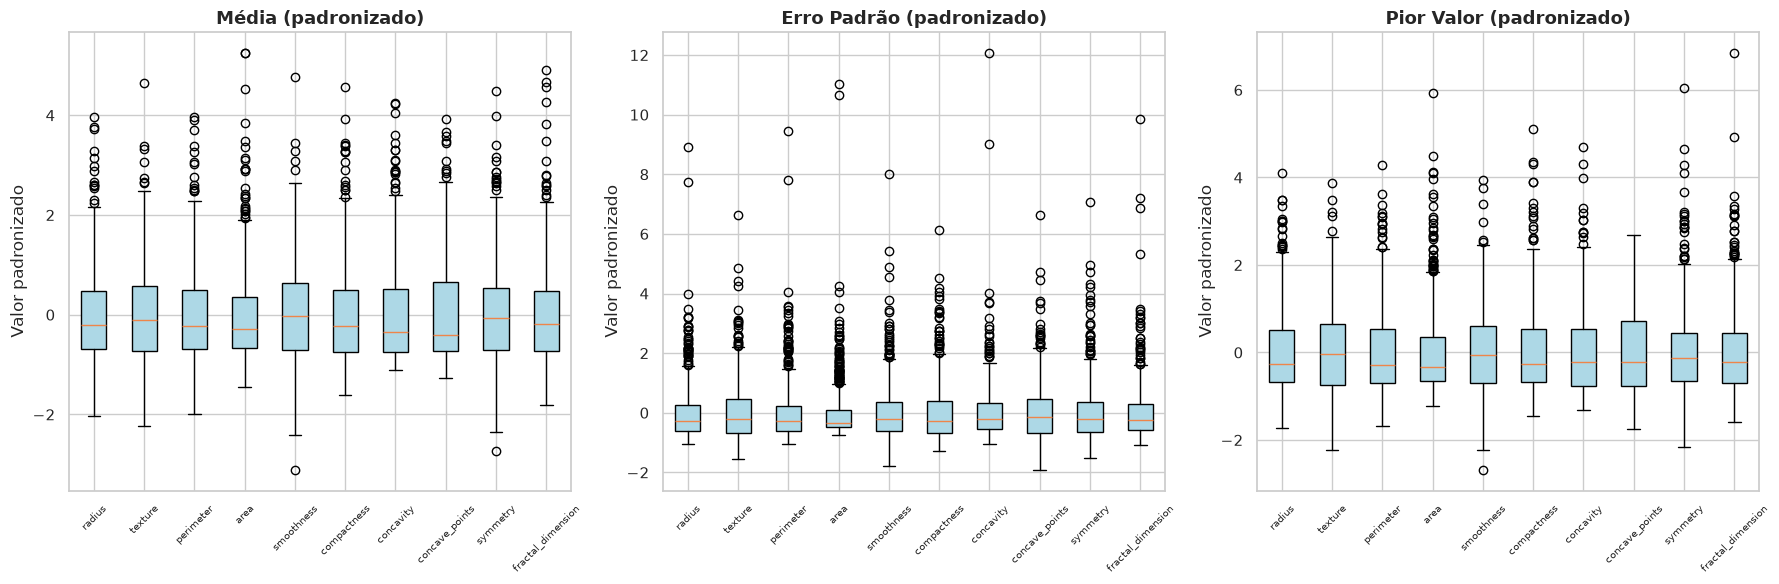

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

feature_groups = {
    'Média': [f for f in feature_names if f.startswith('mean_')],
    'Erro Padrão': [f for f in feature_names if f.startswith('se_')],
    'Pior Valor': [f for f in feature_names if f.startswith('worst_')]
}

for ax, (group_name, cols) in zip(axes, feature_groups.items()):
    df_scaled = (df[cols] - df[cols].mean()) / df[cols].std()
    labels = [c.split('_', 1)[1] for c in cols]
    bp = ax.boxplot(df_scaled.values, patch_artist=True, tick_labels=labels)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.set_title(f'{group_name} (padronizado)', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_ylabel('Valor padronizado')

plt.tight_layout()
plt.savefig('images/02_boxplots_grupos.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Distribuição das features por classe — Histogramas (média)
Para cada feature do grupo 'mean', compara-se a distribuição entre tumores benignos (verde) e malignos (vermelho). Features como `concave_points`, `perimeter` e `area` mostram boa separação entre as classes.

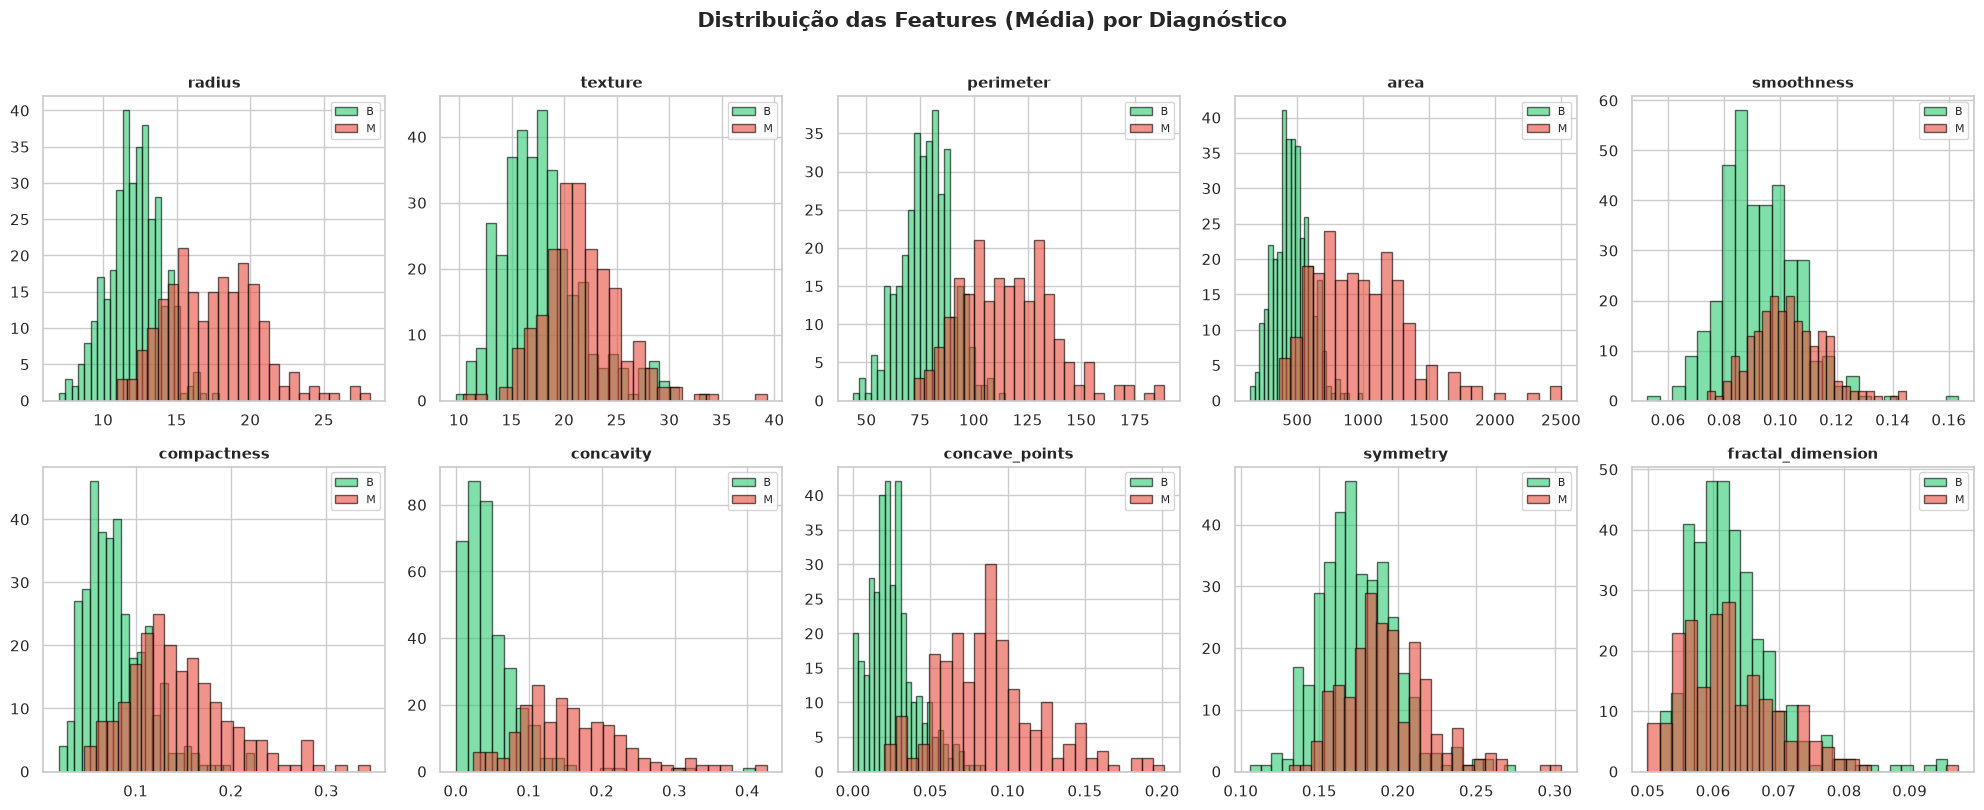

In [7]:
mean_features = [f for f in feature_names if f.startswith('mean_')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, feat in zip(axes, mean_features):
    for label, color in [('B', '#2ecc71'), ('M', '#e74c3c')]:
        subset = df[df['diagnosis'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='black')
    short_name = feat.replace('mean_', '')
    ax.set_title(short_name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Distribuição das Features (Média) por Diagnóstico', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/03_histogramas_mean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Matriz de correlação
Correlação entre as features do grupo 'mean'. `radius`, `perimeter` e `area` são fortemente correlacionadas (esperado, pois são medidas geometricamente relacionadas).

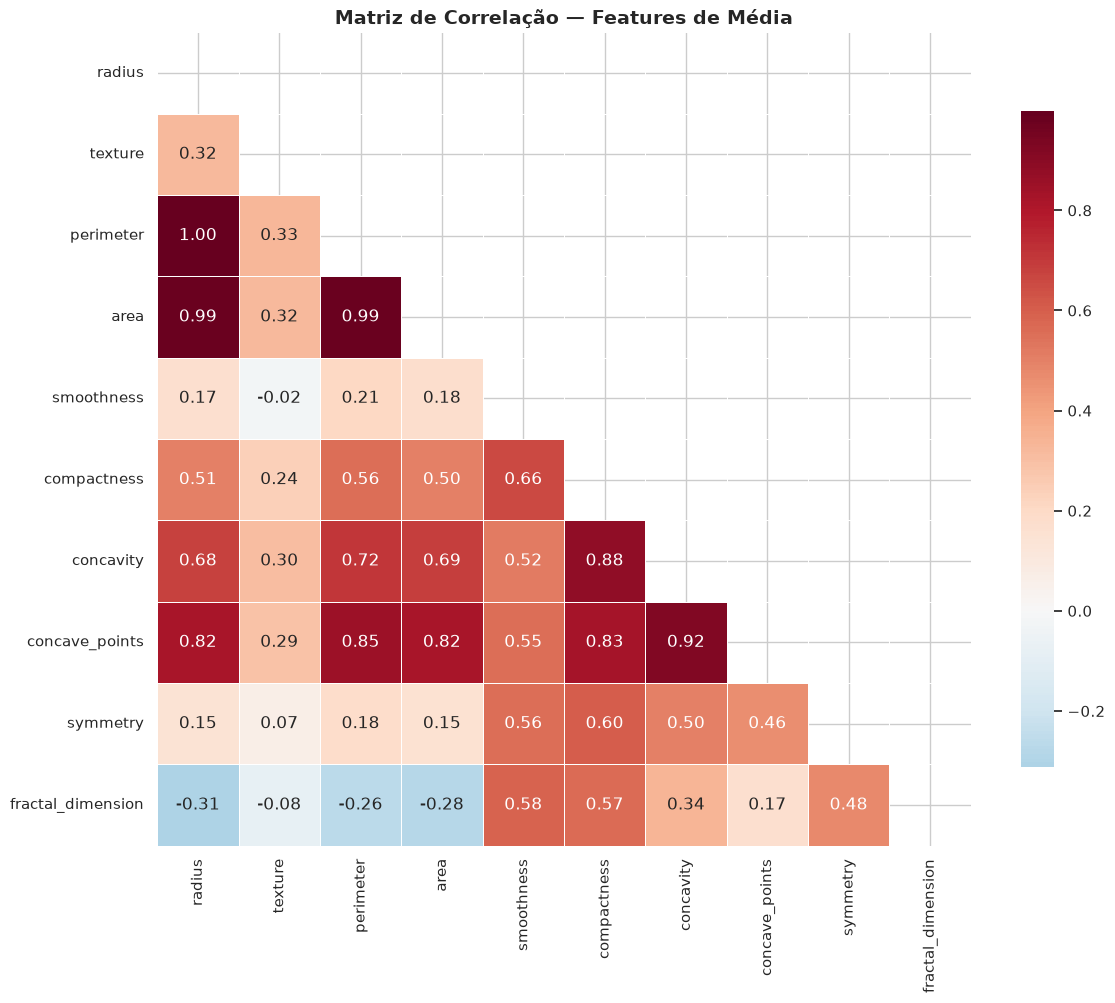

In [8]:
corr = df[mean_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
short_labels = [f.replace('mean_', '') for f in mean_features]
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            xticklabels=short_labels, yticklabels=short_labels,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de Correlação — Features de Média', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/04_correlacao_mean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Pairplot das features mais discriminativas
Visualização das relações bivariadas entre as seis features de média com maior poder discriminativo. A diagonal mostra a densidade (KDE) por classe.

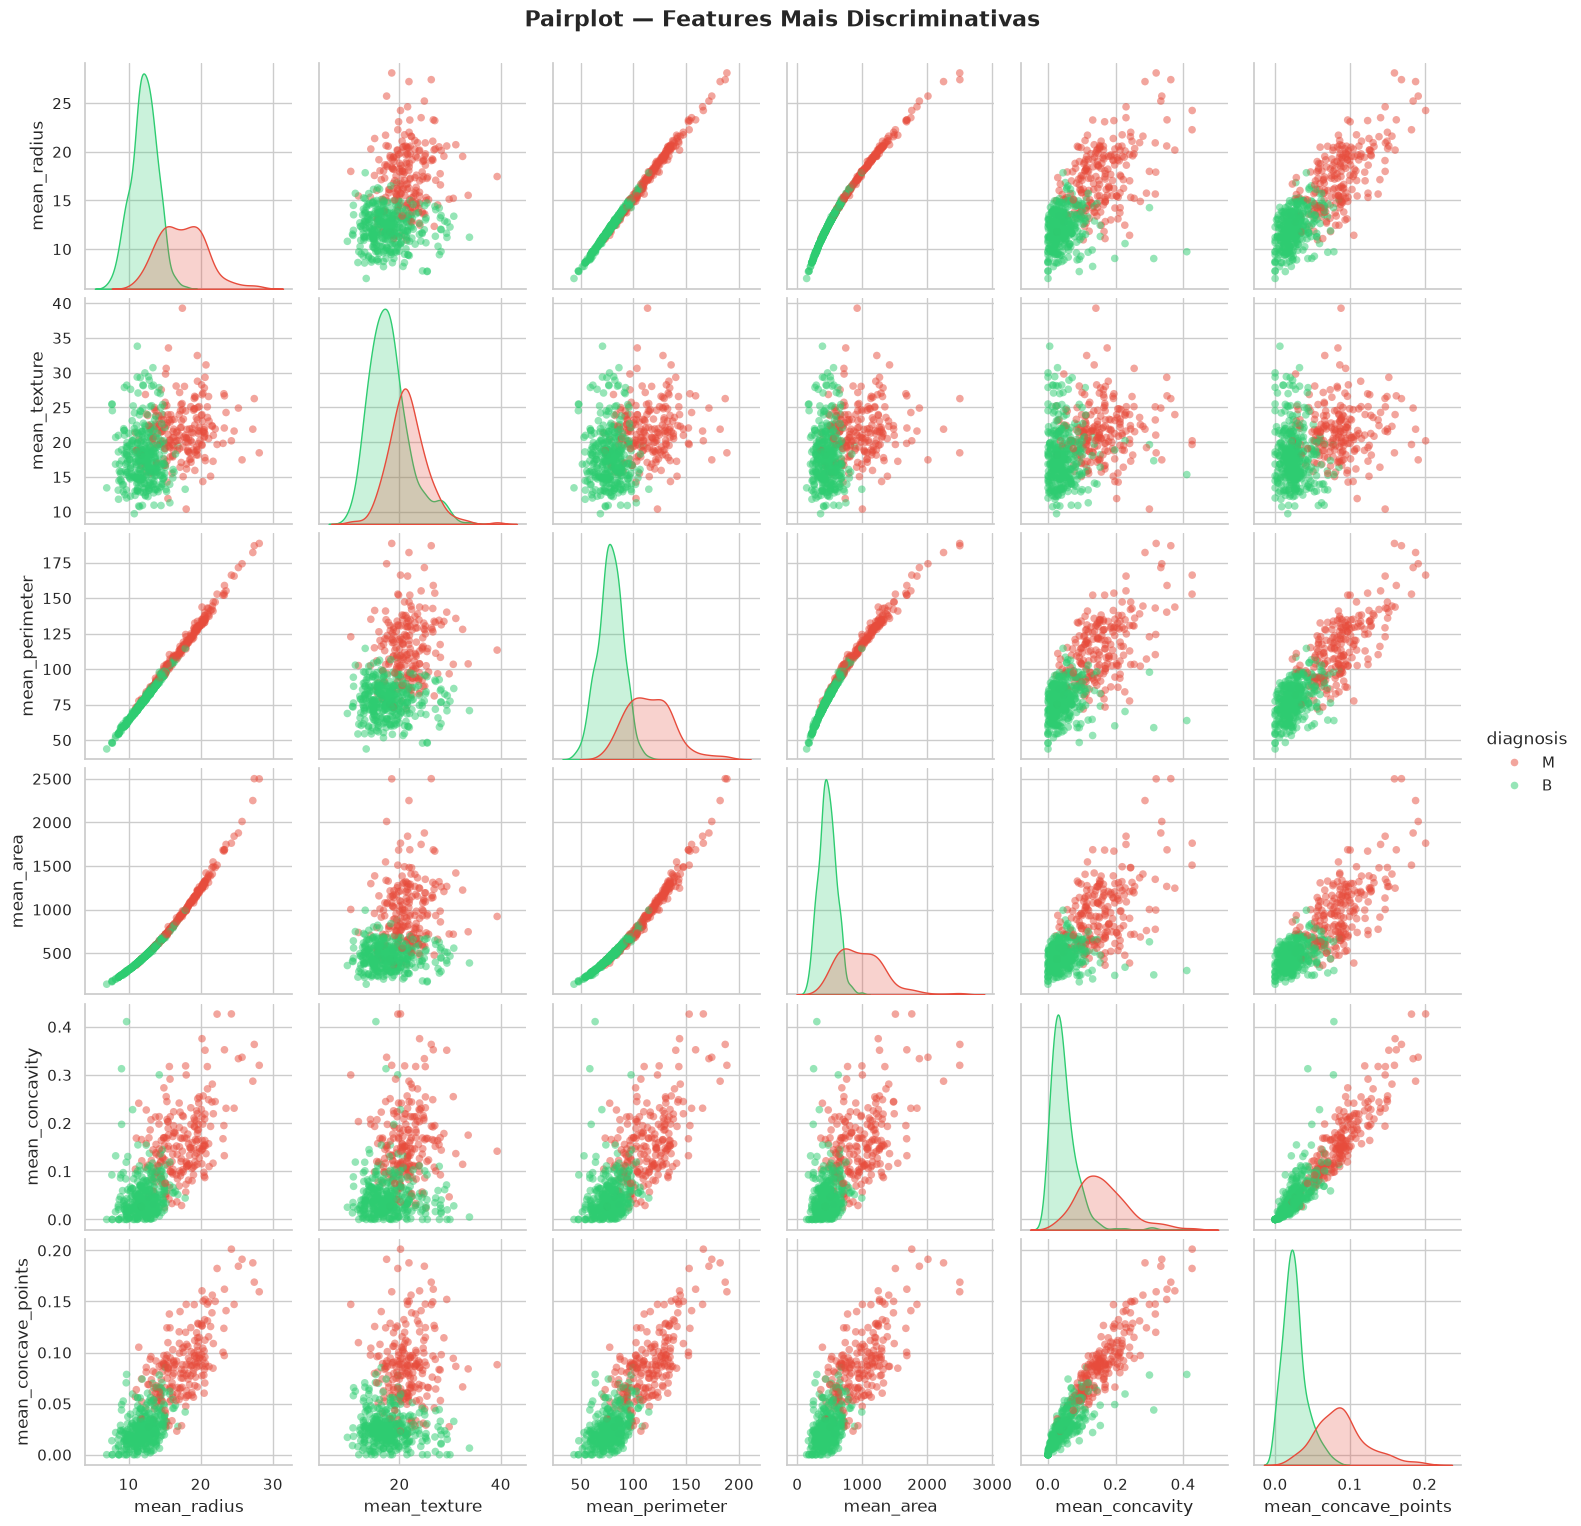

In [9]:
top_features = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
                'mean_concavity', 'mean_concave_points']

g = sns.pairplot(
    df, vars=top_features, hue='diagnosis',
    palette={'B': '#2ecc71', 'M': '#e74c3c'},
    diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'none'}
)
g.fig.suptitle('Pairplot — Features Mais Discriminativas', fontsize=16, fontweight='bold', y=1.02)
g.savefig('images/05_pairplot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Pré-processamento e divisão treino/teste
Padronização via z-score (média 0, desvio 1) e split estratificado 80/20 para preservar a proporção das classes.

In [10]:
X = df[feature_names].values.astype(np.float64)
y = (df['diagnosis'] == 'M').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras ({np.mean(y_train)*100:.1f}% maligno)')
print(f'Teste:  {X_test.shape[0]} amostras ({np.mean(y_test)*100:.1f}% maligno)')

Treino: 455 amostras (37.4% maligno)
Teste:  114 amostras (36.8% maligno)


### Treinamento do modelo base
MLP com arquitetura [30, 64, 32, 2], learning rate 0.01, batch size 32 e inicialização He. Treinamento por 200 épocas.

In [11]:
model = MLP(layer_sizes=[30, 64, 32, 2], learning_rate=0.01, batch_size=32, seed=42)
model.train(X_train, y_train, X_test, y_test, epochs=200, verbose=True)

Epoch    0/200 - train_loss: 0.7572, train_acc: 0.6374 | val_loss: 0.4723, val_acc: 0.7807
Epoch   20/200 - train_loss: 0.0976, train_acc: 0.9604 | val_loss: 0.1118, val_acc: 0.9825


Epoch   40/200 - train_loss: 0.0711, train_acc: 0.9626 | val_loss: 0.0961, val_acc: 0.9825
Epoch   60/200 - train_loss: 0.0589, train_acc: 0.9648 | val_loss: 0.0920, val_acc: 0.9825


Epoch   80/200 - train_loss: 0.0491, train_acc: 0.9670 | val_loss: 0.0905, val_acc: 0.9825
Epoch  100/200 - train_loss: 0.0439, train_acc: 0.9714 | val_loss: 0.0913, val_acc: 0.9825


Epoch  120/200 - train_loss: 0.0395, train_acc: 0.9714 | val_loss: 0.0927, val_acc: 0.9825
Epoch  140/200 - train_loss: 0.0356, train_acc: 0.9736 | val_loss: 0.0938, val_acc: 0.9825


Epoch  160/200 - train_loss: 0.0320, train_acc: 0.9758 | val_loss: 0.0966, val_acc: 0.9825
Epoch  180/200 - train_loss: 0.0291, train_acc: 0.9780 | val_loss: 0.0998, val_acc: 0.9825


Epoch  199/200 - train_loss: 0.0264, train_acc: 0.9802 | val_loss: 0.1027, val_acc: 0.9825


### Curvas de treinamento: loss e acurácia
Evolução da loss (cross-entropy) e acurácia ao longo das épocas, tanto no treino quanto no teste.

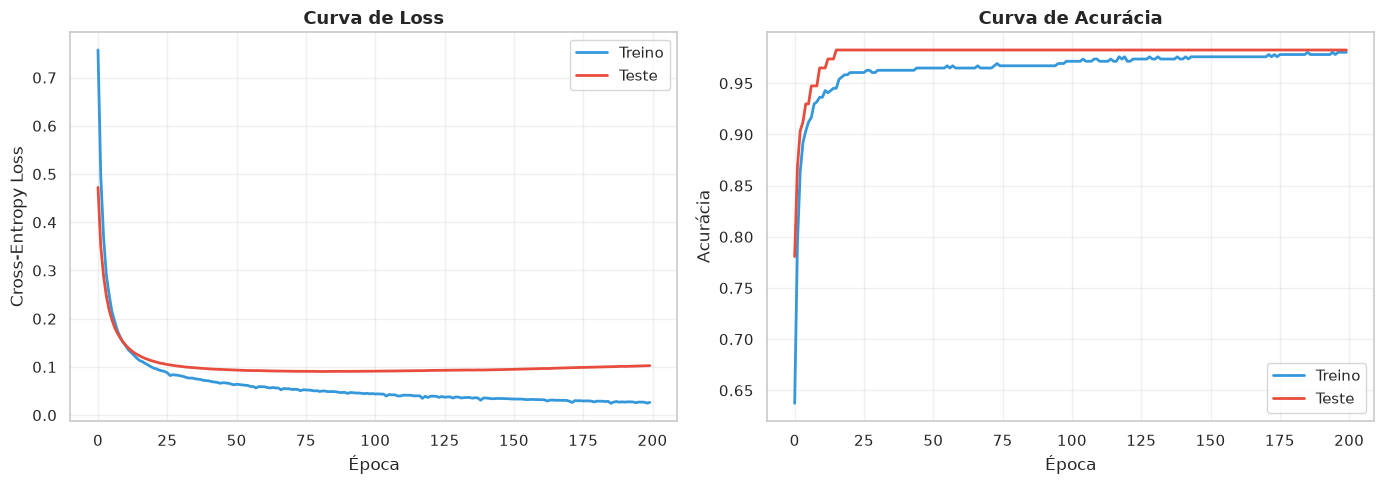

Treino final: loss=0.0265, acurácia=0.9956
Teste final:  loss=0.1027, acurácia=0.9825


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model.train_loss, label='Treino', color='#3498db', linewidth=2)
axes[0].plot(model.val_loss, label='Teste', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Curva de Loss', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(model.train_acc, label='Treino', color='#3498db', linewidth=2)
axes[1].plot(model.val_acc, label='Teste', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Curva de Acurácia', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/06_curvas_treinamento.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Treino final: loss={train_loss:.4f}, acurácia={train_acc:.4f}')
print(f'Teste final:  loss={test_loss:.4f}, acurácia={test_acc:.4f}')

### Experimento: impacto da taxa de aprendizado
Quatro valores de learning rate (0.001, 0.01, 0.05, 0.10) testados com a mesma arquitetura e batch size. LR muito alto (0.1) pode divergir; muito baixo (0.001) converge lentamente.

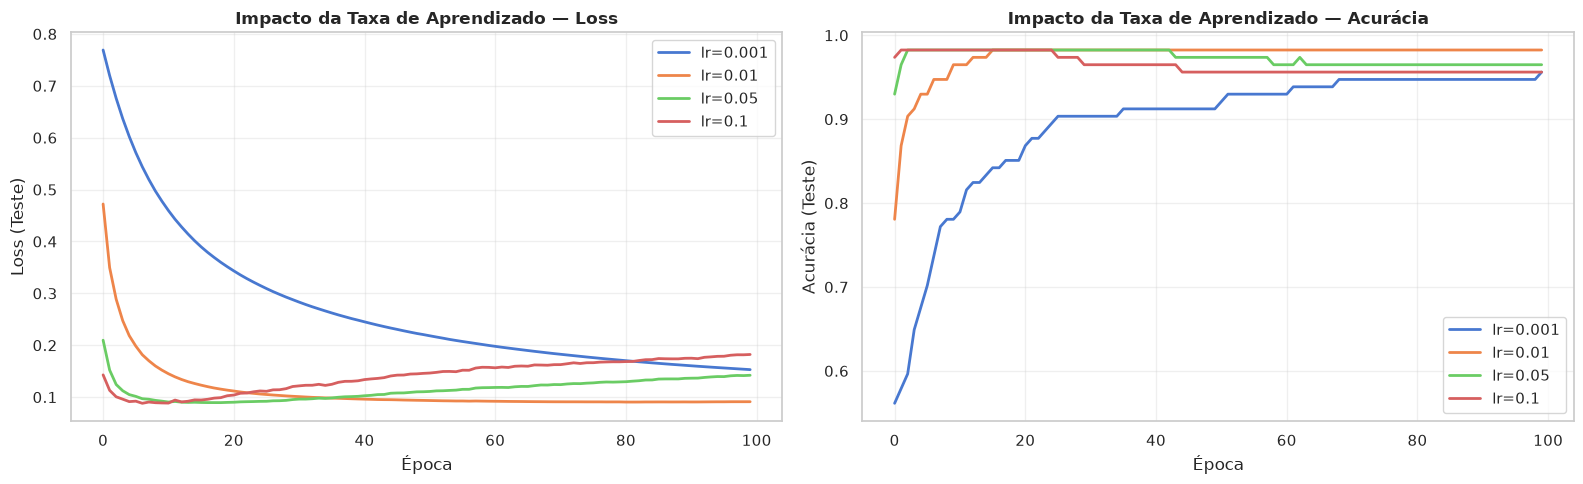

In [13]:
learning_rates = [0.001, 0.01, 0.05, 0.1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for lr in learning_rates:
    m = MLP(layer_sizes=[30, 64, 32, 2], learning_rate=lr, batch_size=32, seed=42)
    m.train(X_train, y_train, X_test, y_test, epochs=100, verbose=False)
    axes[0].plot(m.val_loss, label=f'lr={lr}', linewidth=2)
    axes[1].plot(m.val_acc, label=f'lr={lr}', linewidth=2)

axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (Teste)')
axes[0].set_title('Impacto da Taxa de Aprendizado — Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (Teste)')
axes[1].set_title('Impacto da Taxa de Aprendizado — Acurácia', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/07_experimento_lr.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Experimento: impacto do tamanho do batch
Cinco valores de batch size (8, 16, 32, 64, 128). Batch menor tem mais ruído nos gradientes; batch maior converge de forma mais estável, porém mais lenta.

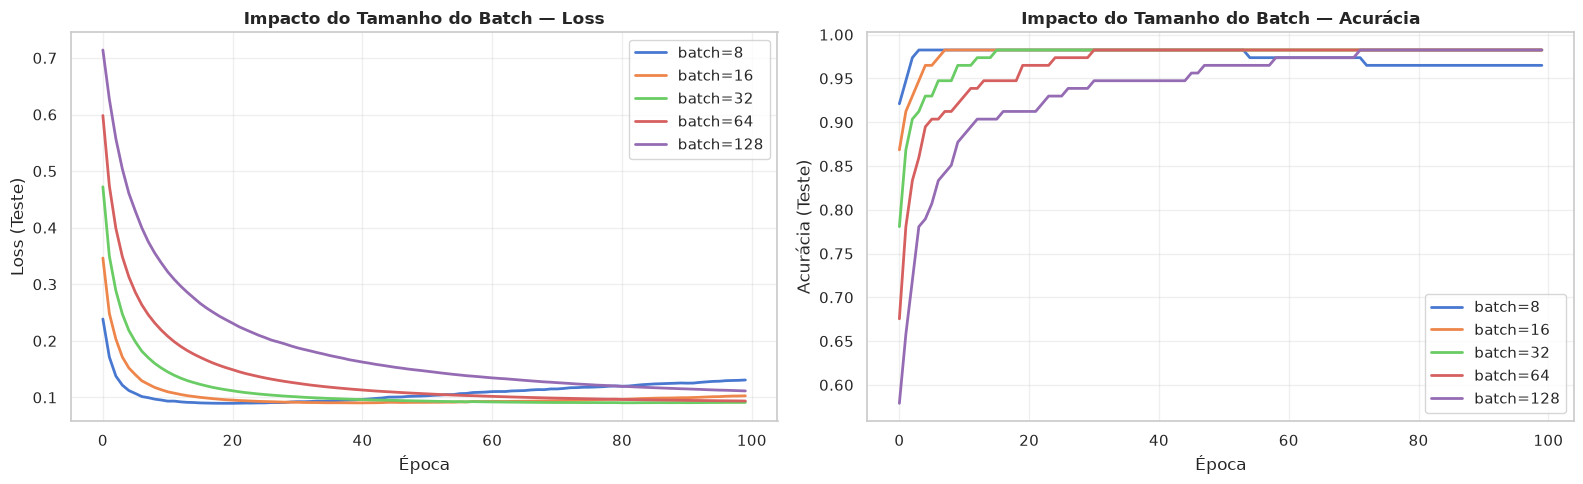

In [14]:
batch_sizes = [8, 16, 32, 64, 128]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for bs in batch_sizes:
    m = MLP(layer_sizes=[30, 64, 32, 2], learning_rate=0.01, batch_size=bs, seed=42)
    m.train(X_train, y_train, X_test, y_test, epochs=100, verbose=False)
    axes[0].plot(m.val_loss, label=f'batch={bs}', linewidth=2)
    axes[1].plot(m.val_acc, label=f'batch={bs}', linewidth=2)

axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (Teste)')
axes[0].set_title('Impacto do Tamanho do Batch — Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (Teste)')
axes[1].set_title('Impacto do Tamanho do Batch — Acurácia', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/08_experimento_batch.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Experimento: impacto da arquitetura da rede
Comparação entre cinco arquiteturas: uma camada (16, 32 ou 64 neurônios) e duas camadas (64+32 ou 128+64). Redes mais profundas e com mais neurônios tendem a performar melhor, mas com rendimento decrescente.

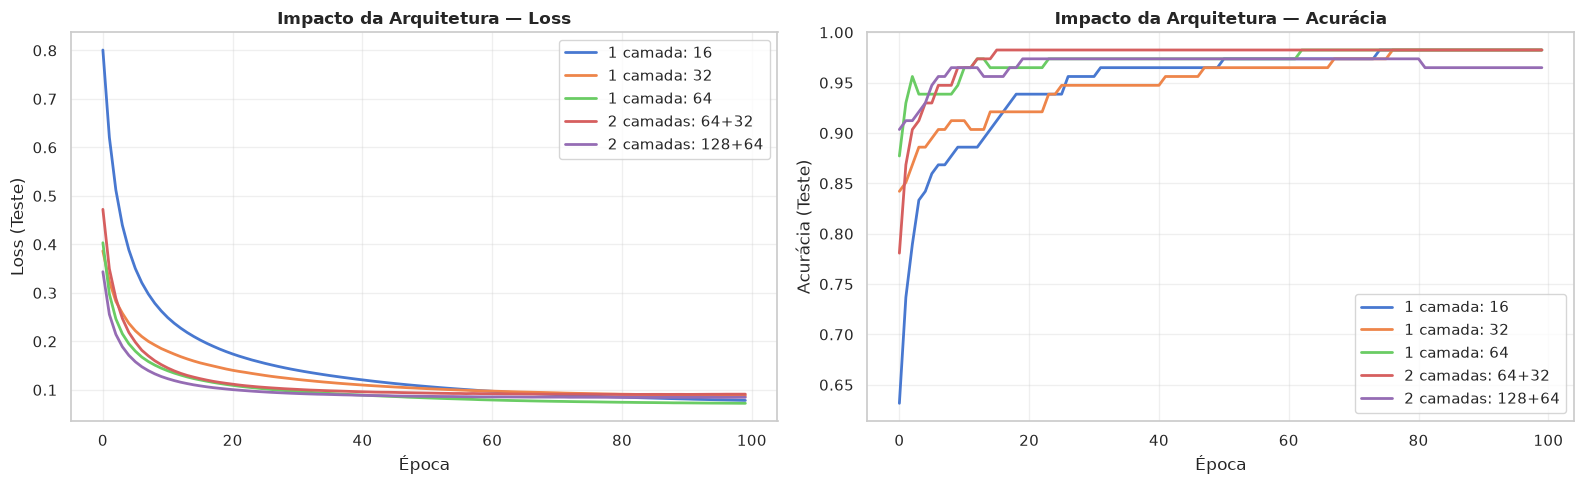

,Arquitetura,Acurácia (Teste),Loss (Teste)
0,1 camada: 16,0.9825,0.0783
1,1 camada: 32,0.9825,0.0877
2,1 camada: 64,0.9825,0.0723
3,2 camadas: 64+32,0.9825,0.0912
4,2 camadas: 128+64,0.9649,0.0847


In [15]:
architectures = [
    ([30, 16, 2], '1 camada: 16'),
    ([30, 32, 2], '1 camada: 32'),
    ([30, 64, 2], '1 camada: 64'),
    ([30, 64, 32, 2], '2 camadas: 64+32'),
    ([30, 128, 64, 2], '2 camadas: 128+64'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
results = []

for arch, label in architectures:
    m = MLP(layer_sizes=arch, learning_rate=0.01, batch_size=32, seed=42)
    m.train(X_train, y_train, X_test, y_test, epochs=100, verbose=False)
    axes[0].plot(m.val_loss, label=label, linewidth=2)
    axes[1].plot(m.val_acc, label=label, linewidth=2)
    results.append({'Arquitetura': label, 'Acurácia (Teste)': f'{m.val_acc[-1]:.4f}', 'Loss (Teste)': f'{m.val_loss[-1]:.4f}'})

axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (Teste)')
axes[0].set_title('Impacto da Arquitetura — Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (Teste)')
axes[1].set_title('Impacto da Arquitetura — Acurácia', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/09_experimento_arquitetura.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
pd.DataFrame(results)

### Interpretabilidade — Técnica 1: Saliency Maps (Gradientes)
Calcula-se a magnitude do gradiente da predição em relação a cada feature de entrada. Indica quais features o modelo considera localmente mais sensíveis para cada decisão. O gráfico mostra a média dos valores absolutos dos gradientes sobre o conjunto de teste.

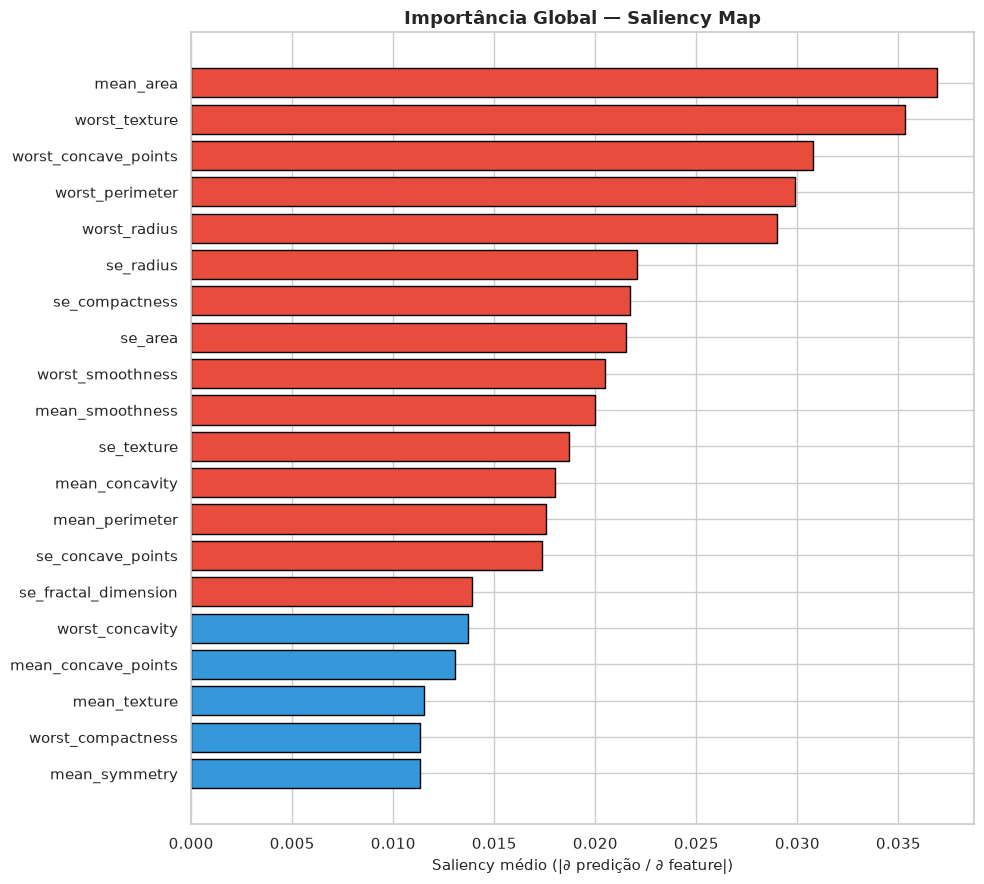

Top 10 features por saliency:
  mean_area                       0.0369
  worst_texture                   0.0353
  worst_concave_points            0.0308
  worst_perimeter                 0.0299
  worst_radius                    0.0290
  se_radius                       0.0221
  se_compactness                  0.0217
  se_area                         0.0215
  worst_smoothness                0.0205
  mean_smoothness                 0.0200


In [16]:
saliency_all = model.saliency_map(X_test)
mean_saliency = np.mean(saliency_all, axis=0)

saliency_df = pd.DataFrame({
    'feature': feature_names,
    'saliency': mean_saliency
}).sort_values('saliency', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
top_sal = saliency_df.tail(20)
colors = ['#e74c3c' if v > np.median(mean_saliency) else '#3498db' for v in top_sal['saliency']]
ax.barh(top_sal['feature'], top_sal['saliency'], color=colors, edgecolor='black')
ax.set_xlabel('Saliency médio (|∂ predição / ∂ feature|)', fontsize=11)
ax.set_title('Importância Global — Saliency Map', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/10_interpretabilidade_saliency.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('Top 10 features por saliency:')
for _, row in saliency_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:30s}  {row['saliency']:.4f}")

### Interpretabilidade — Técnica 2: Perturbação (Occlusion)
Zera-se cada feature individualmente e mede-se a queda resultante na probabilidade da classe predita. Quanto maior a queda, mais importante é a feature para aquela decisão.

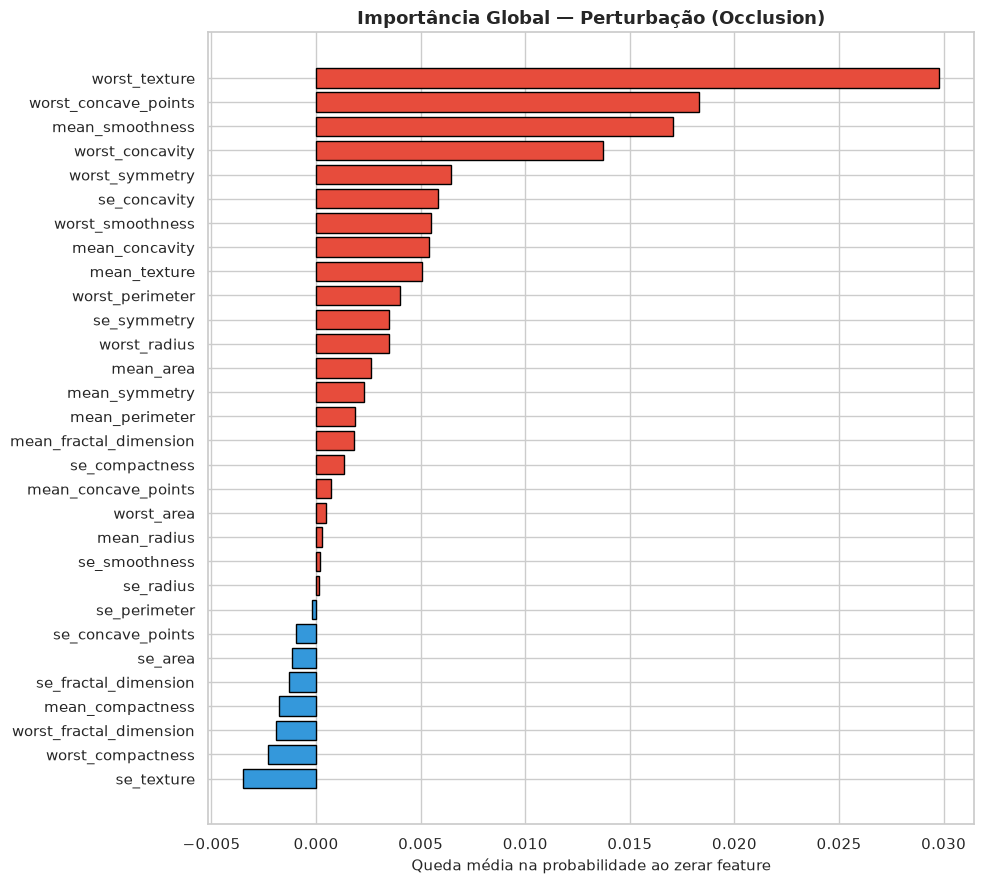

Top 10 features por perturbação:
  worst_texture                   0.0298
  worst_concave_points            0.0183
  mean_smoothness                 0.0171
  worst_concavity                 0.0137
  worst_symmetry                  0.0064
  se_concavity                    0.0058
  worst_smoothness                0.0055
  mean_concavity                  0.0054
  mean_texture                    0.0051
  worst_perimeter                 0.0040


In [17]:
n_pert = min(100, X_test.shape[0])
pert_importance = model.perturbation_importance(X_test[:n_pert], method='zero')
mean_pert = np.mean(pert_importance, axis=0)

pert_df = pd.DataFrame({
    'feature': feature_names,
    'perturbacao': mean_pert
}).sort_values('perturbacao', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in pert_df['perturbacao']]
ax.barh(pert_df['feature'], pert_df['perturbacao'], color=colors, edgecolor='black')
ax.set_xlabel('Queda média na probabilidade ao zerar feature', fontsize=11)
ax.set_title('Importância Global — Perturbação (Occlusion)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/11_interpretabilidade_perturbacao.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('Top 10 features por perturbação:')
for _, row in pert_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:30s}  {row['perturbacao']:.4f}")

### Interpretabilidade — Técnica 3: Ablação
Remove-se completamente uma feature do modelo (excluindo a linha correspondente da matriz de pesos $W_0$) e mede-se o impacto na predição. Mais custosa que as anteriores, porém avalia a importância real da feature no contexto completo.

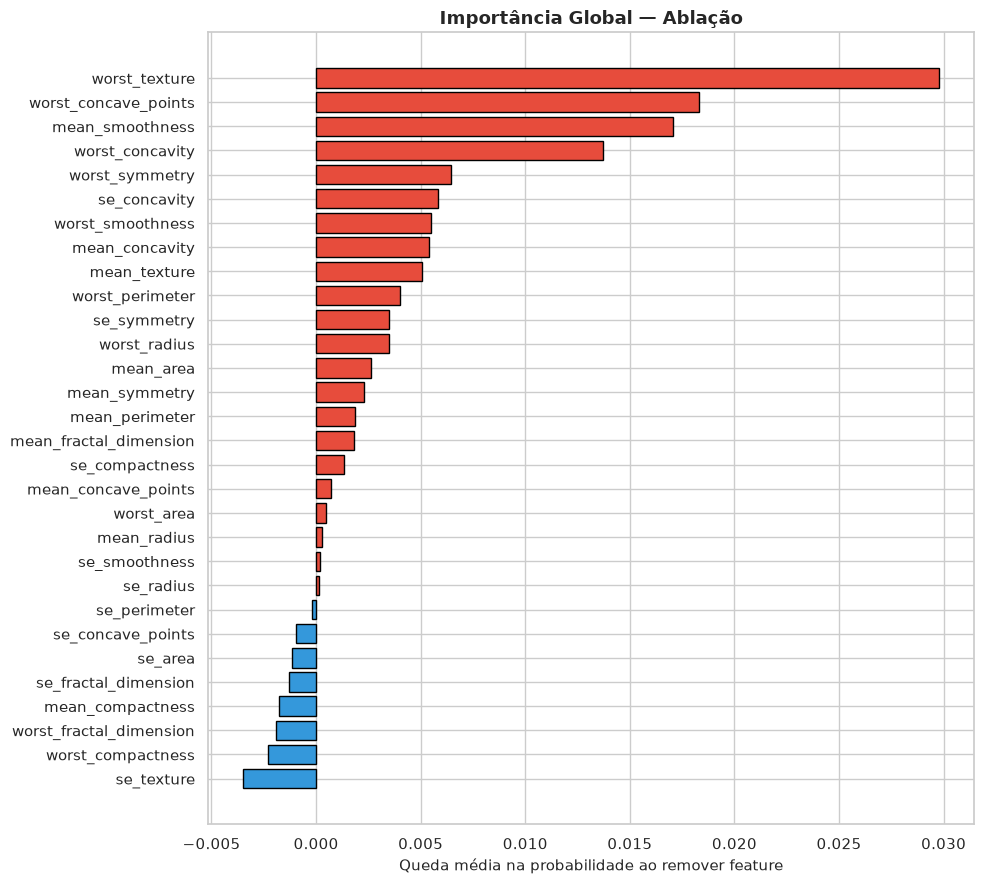

Top 10 features por ablação:
  worst_texture                   0.0298
  worst_concave_points            0.0183
  mean_smoothness                 0.0171
  worst_concavity                 0.0137
  worst_symmetry                  0.0064
  se_concavity                    0.0058
  worst_smoothness                0.0055
  mean_concavity                  0.0054
  mean_texture                    0.0051
  worst_perimeter                 0.0040


In [18]:
n_ablate = min(100, X_test.shape[0])
ablation_imp = model.ablation_importance(X_test[:n_ablate])

ablation_df = pd.DataFrame({
    'feature': feature_names,
    'ablacao': ablation_imp
}).sort_values('ablacao', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in ablation_df['ablacao']]
ax.barh(ablation_df['feature'], ablation_df['ablacao'], color=colors, edgecolor='black')
ax.set_xlabel('Queda média na probabilidade ao remover feature', fontsize=11)
ax.set_title('Importância Global — Ablação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/12_interpretabilidade_ablacao.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('Top 10 features por ablação:')
for _, row in ablation_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:30s}  {row['ablacao']:.4f}")

### Explicação de decisões individuais
Quatro casos analisados em profundidade: verdadeiro positivo (maligno correto), verdadeiro negativo (benigno correto), falso negativo (maligno não detectado) e falso positivo (alarme falso). Para cada caso, mostram-se as 10 features mais relevantes combinando as três técnicas. O gráfico à esquerda mostra o saliency map; o da direita compara as três técnicas normalizadas.

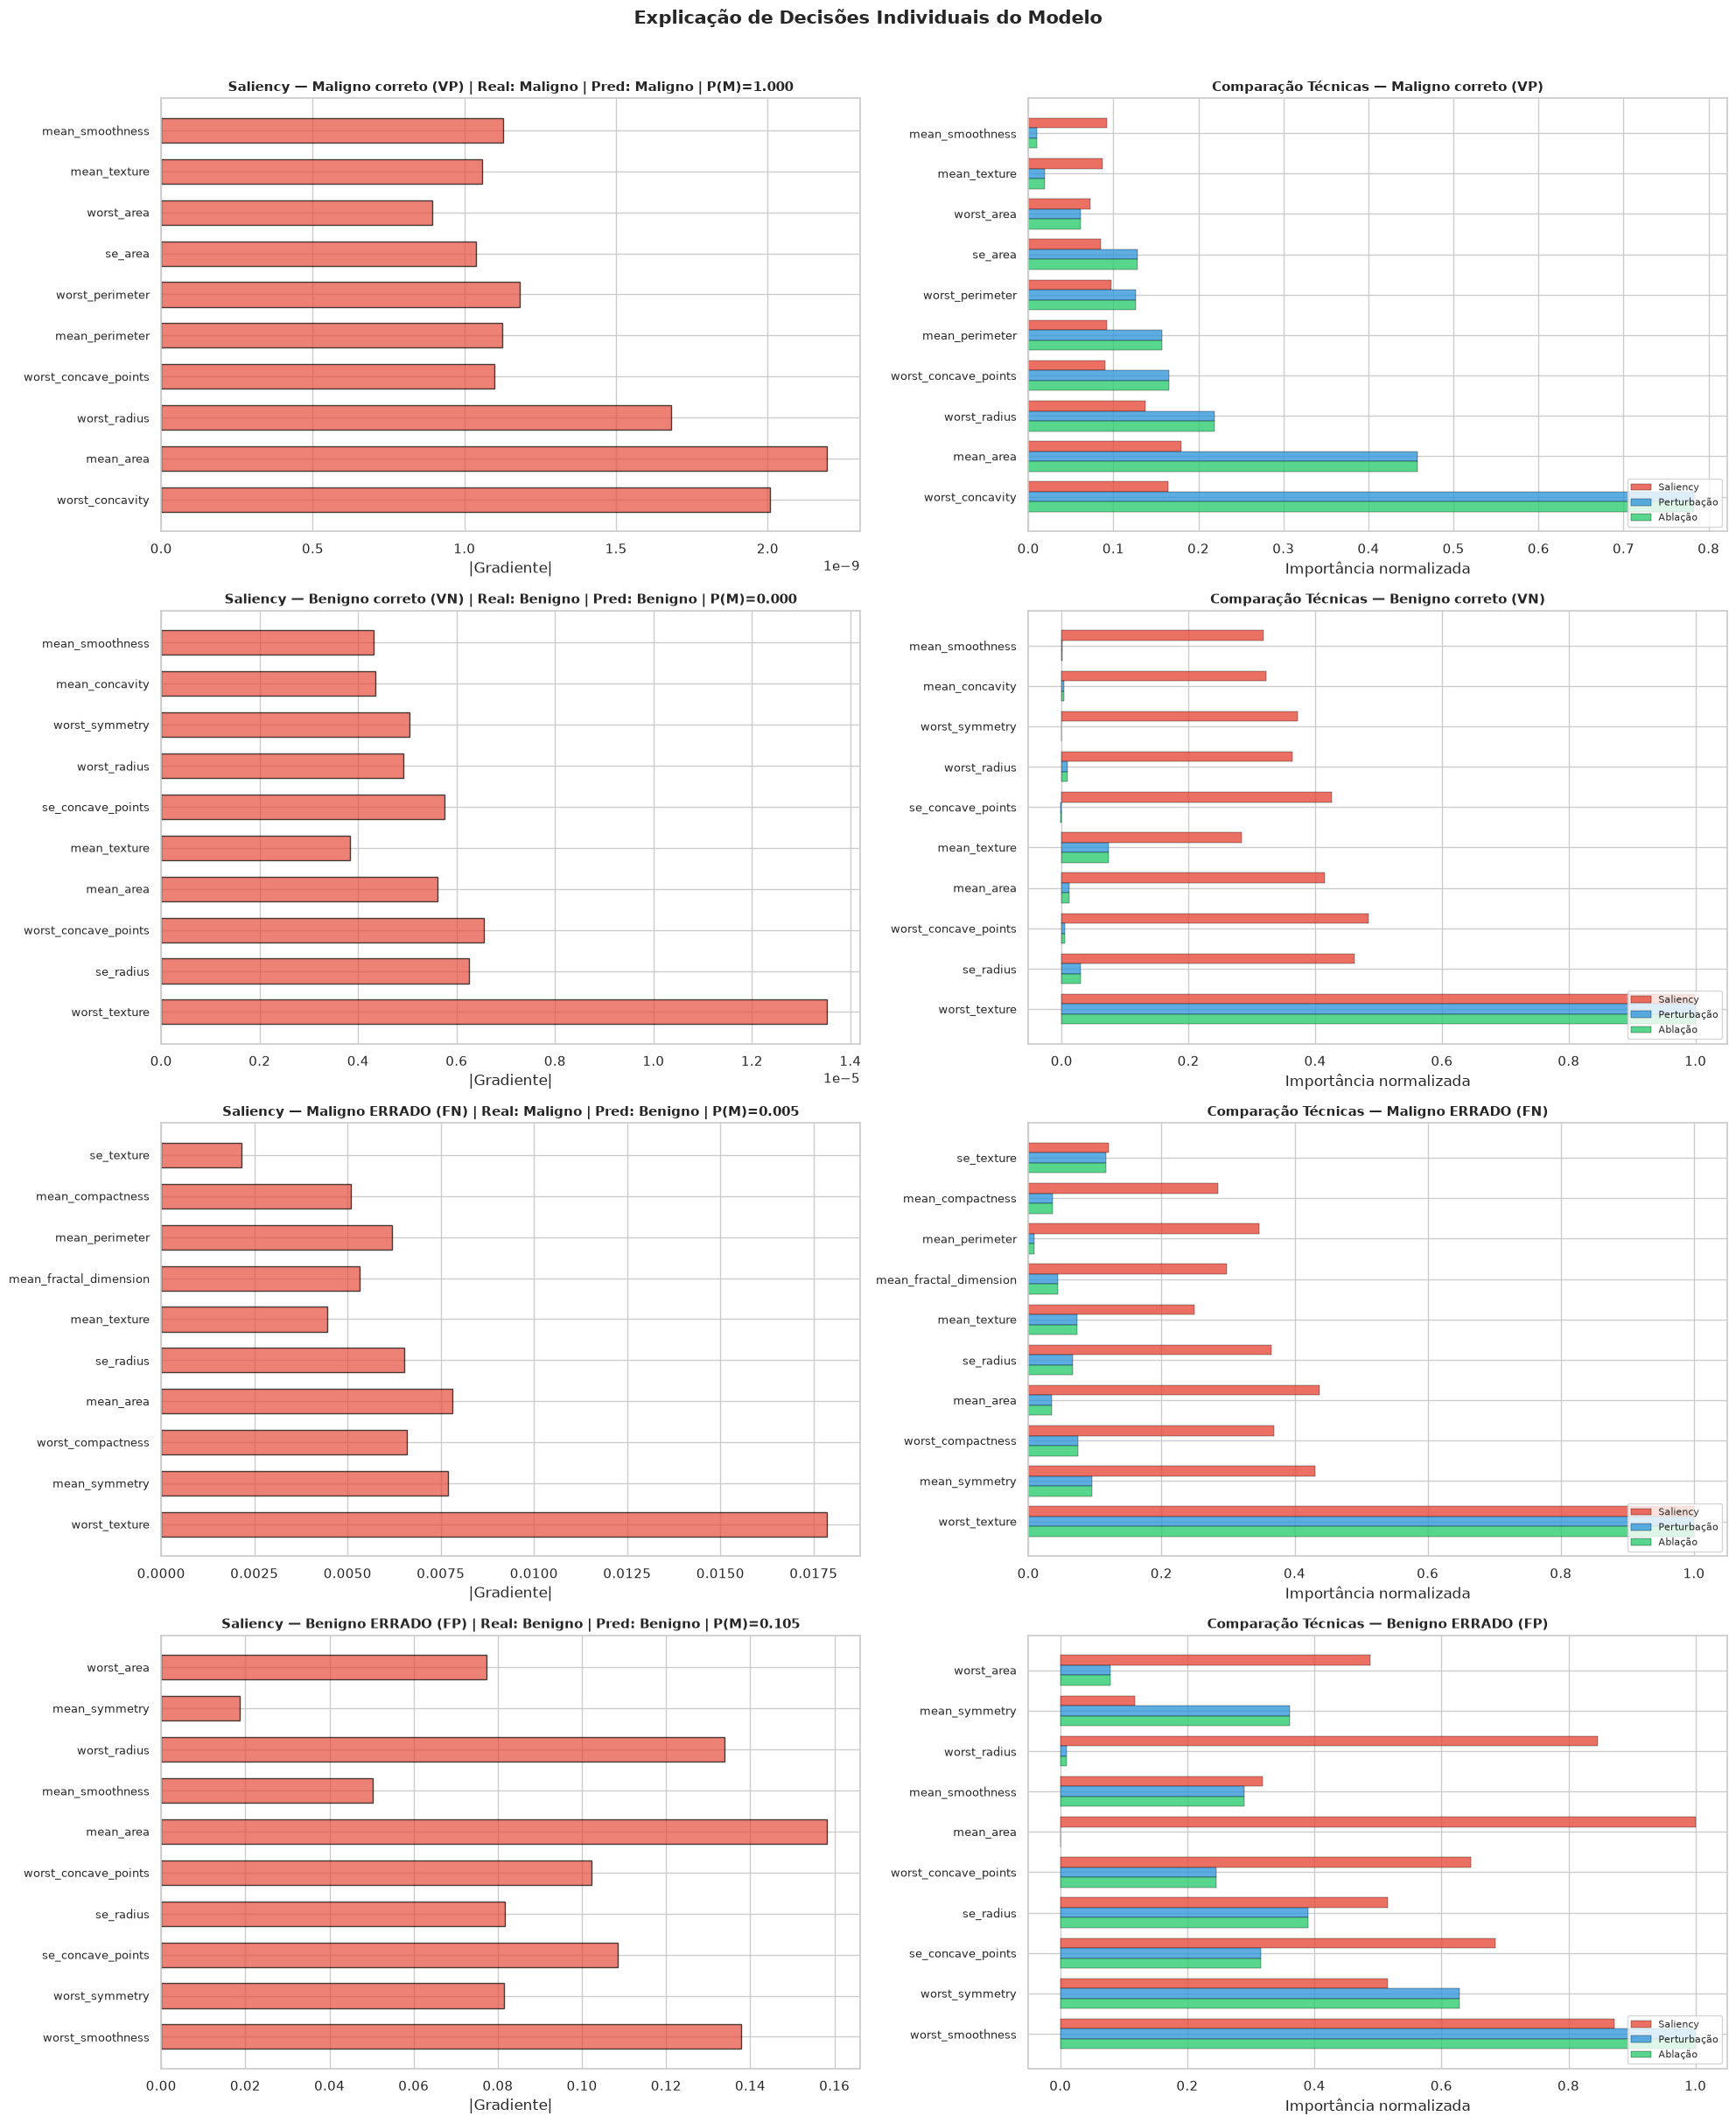

In [19]:
preds = model.predict(X_test)
correct_m = np.where((y_test == 1) & (preds == 1))[0]
correct_b = np.where((y_test == 0) & (preds == 0))[0]
wrong_m = np.where((y_test == 1) & (preds == 0))[0]
wrong_b = np.where((y_test == 0) & (preds == 1))[0]

cases = [
    (correct_m[0], 'Maligno correto (VP)'),
    (correct_b[0], 'Benigno correto (VN)'),
    (wrong_m[0] if len(wrong_m) > 0 else correct_m[-1], 'Maligno ERRADO (FN)'),
    (wrong_b[0] if len(wrong_b) > 0 else correct_b[-1], 'Benigno ERRADO (FP)'),
]

fig, axes = plt.subplots(4, 2, figsize=(20, 24))

for row, (idx, title) in enumerate(cases):
    x = X_test[idx:idx+1]
    exp = model.explain_prediction(x)
    true_label = 'Maligno' if y_test[idx] == 1 else 'Benigno'
    pred_label = 'Maligno' if exp['predicted_class'] == 1 else 'Benigno'
    prob_m = exp['probabilities'][1]

    subtitle = f'{title} | Real: {true_label} | Pred: {pred_label} | P(M)={prob_m:.3f}'

    sal = np.array(exp['saliency'])
    pert = np.array(exp['perturbation_importance'])
    abl = np.array(exp['ablation_importance'])

    combined = (sal / (np.max(sal) + 1e-8) + pert / (np.max(np.abs(pert)) + 1e-8) + abl / (np.max(np.abs(abl)) + 1e-8)) / 3
    top_idx = np.argsort(combined)[-10:]
    top_feats = [feature_names[i] for i in top_idx]

    ax1 = axes[row, 0]
    ax1.barh(np.arange(len(top_idx)), sal[top_idx], color='#e74c3c', alpha=0.7, edgecolor='black', height=0.6)
    ax1.set_yticks(np.arange(len(top_idx)))
    ax1.set_yticklabels(top_feats, fontsize=9)
    ax1.set_xlabel('|Gradiente|')
    ax1.set_title(f'Saliency — {subtitle}', fontsize=11, fontweight='bold')
    ax1.invert_yaxis()

    ax2 = axes[row, 1]
    methods_data = {'Saliency': sal, 'Perturbação': pert, 'Ablação': abl}
    x_pts = np.arange(len(top_idx))
    width = 0.25
    colors_method = ['#e74c3c', '#3498db', '#2ecc71']
    for j, (name, values) in enumerate(methods_data.items()):
        vals = values[top_idx]
        vals = vals / (np.max(np.abs(vals)) + 1e-8)
        ax2.barh(x_pts + (j - 1) * width, vals, width,
                 label=name, alpha=0.8, color=colors_method[j], edgecolor='black', linewidth=0.3)
    ax2.set_yticks(x_pts)
    ax2.set_yticklabels(top_feats, fontsize=9)
    ax2.set_xlabel('Importância normalizada')
    ax2.set_title(f'Comparação Técnicas — {title}', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=8, loc='lower right')
    ax2.invert_yaxis()

fig.suptitle('Explicação de Decisões Individuais do Modelo', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/13_decisoes_individuais.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Curva de impacto cumulativo (ablação progressiva)
As features são zeradas uma a uma em ordem decrescente de importância (segundo a ablação) e a acurácia é medida após cada remoção. Mostra quantas features são realmente necessárias para manter uma boa performance.

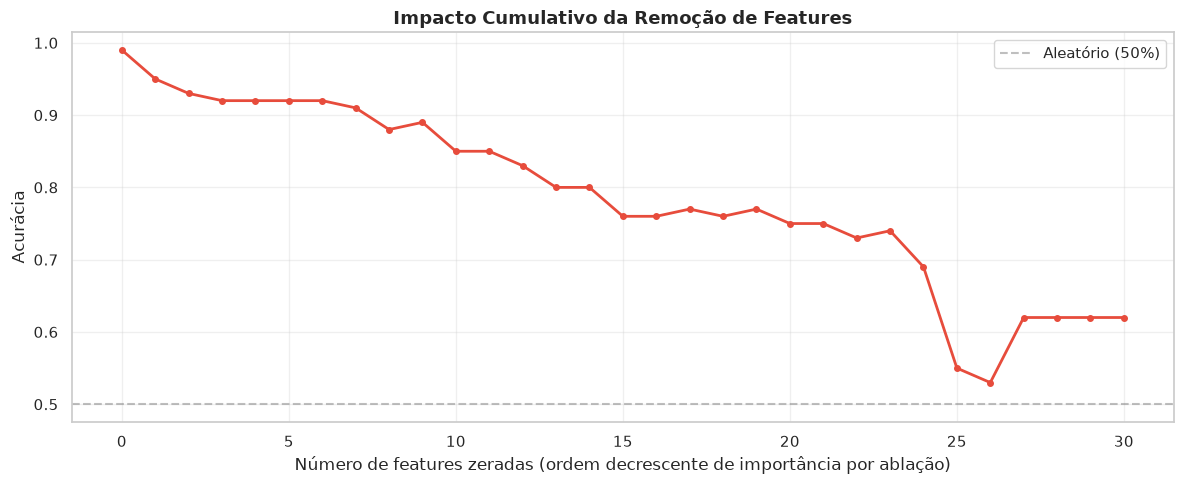

In [20]:
ranked_features = ablation_df.sort_values('ablacao', ascending=False)['feature'].values
n_curve = min(100, X_test.shape[0])
X_curve = X_test[:n_curve].copy()

acc_curve = []
acc = model.evaluate(X_curve, y_test[:n_curve])[1]
acc_curve.append(acc)

for feat in ranked_features:
    feat_idx = feature_names.index(feat)
    X_curve[:, feat_idx] = 0
    acc = model.evaluate(X_curve, y_test[:n_curve])[1]
    acc_curve.append(acc)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(acc_curve)), acc_curve, 'o-', color='#e74c3c', linewidth=2, markersize=4)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Aleatório (50%)')
ax.set_xlabel('Número de features zeradas (ordem decrescente de importância por ablação)')
ax.set_ylabel('Acurácia')
ax.set_title('Impacto Cumulativo da Remoção de Features', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/14_ablacao_cumulativa.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()